### LOAD DATA

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv("smartcart_customers.csv")


In [3]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [4]:
df.shape

(2240, 22)

In [5]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
Complain                0
Response                0
dtype: int64

## DATA PREPROCESSING

## 1.Handle Missing Value

In [6]:
df["Income"] = df["Income"].fillna(df["Income"].median())

In [7]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


### Feature engineering


In [8]:
#Age 
df["Age"] =  2026-df["Year_Birth"]

In [9]:
# Customer Joining Date
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst = True)

reference_Date  = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (reference_Date - df["Dt_Customer"]).dt.days

In [10]:
#Spending
df["Total_spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntSweetProducts"] +  df["MntGoldProds"]

In [11]:
# Children 
df["Total_children"] = df["Kidhome"]  + df["Teenhome"]

In [12]:
# Education

df["Education"].value_counts()

df["Education"] = df["Education"].replace({
    "Basic": "Undergraduate", "2n Cycle": "Undergraduate",
    "Graduation": "Graduate",
    "Master": "Postgraduate", "PhD": "Postgraduate"
})

In [13]:

df["Education"].value_counts()

Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [14]:
# Marital Status

df["Living_With"] = df["Marital_Status"].replace({
    "Married": "Partner", "Together": "Partner",
    "Single": "Alone", "Divorced": "Alone",
    "Widow": "Alone", "Absurd": "Alone", "YOLO": "Alone"
})

In [15]:
df["Living_With"].value_counts()


Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

### Drop Columns

In [16]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_children,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1445,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,25,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,665,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,43,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,376,1,Partner


In [17]:
cols = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols = ["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]

cols_to_drop = cols + spending_cols

df_cleaned = df.drop(columns=cols_to_drop)

In [18]:
df_cleaned.shape

(2240, 15)

In [19]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1445,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,25,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,665,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,43,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,376,1,Partner


### Outliers

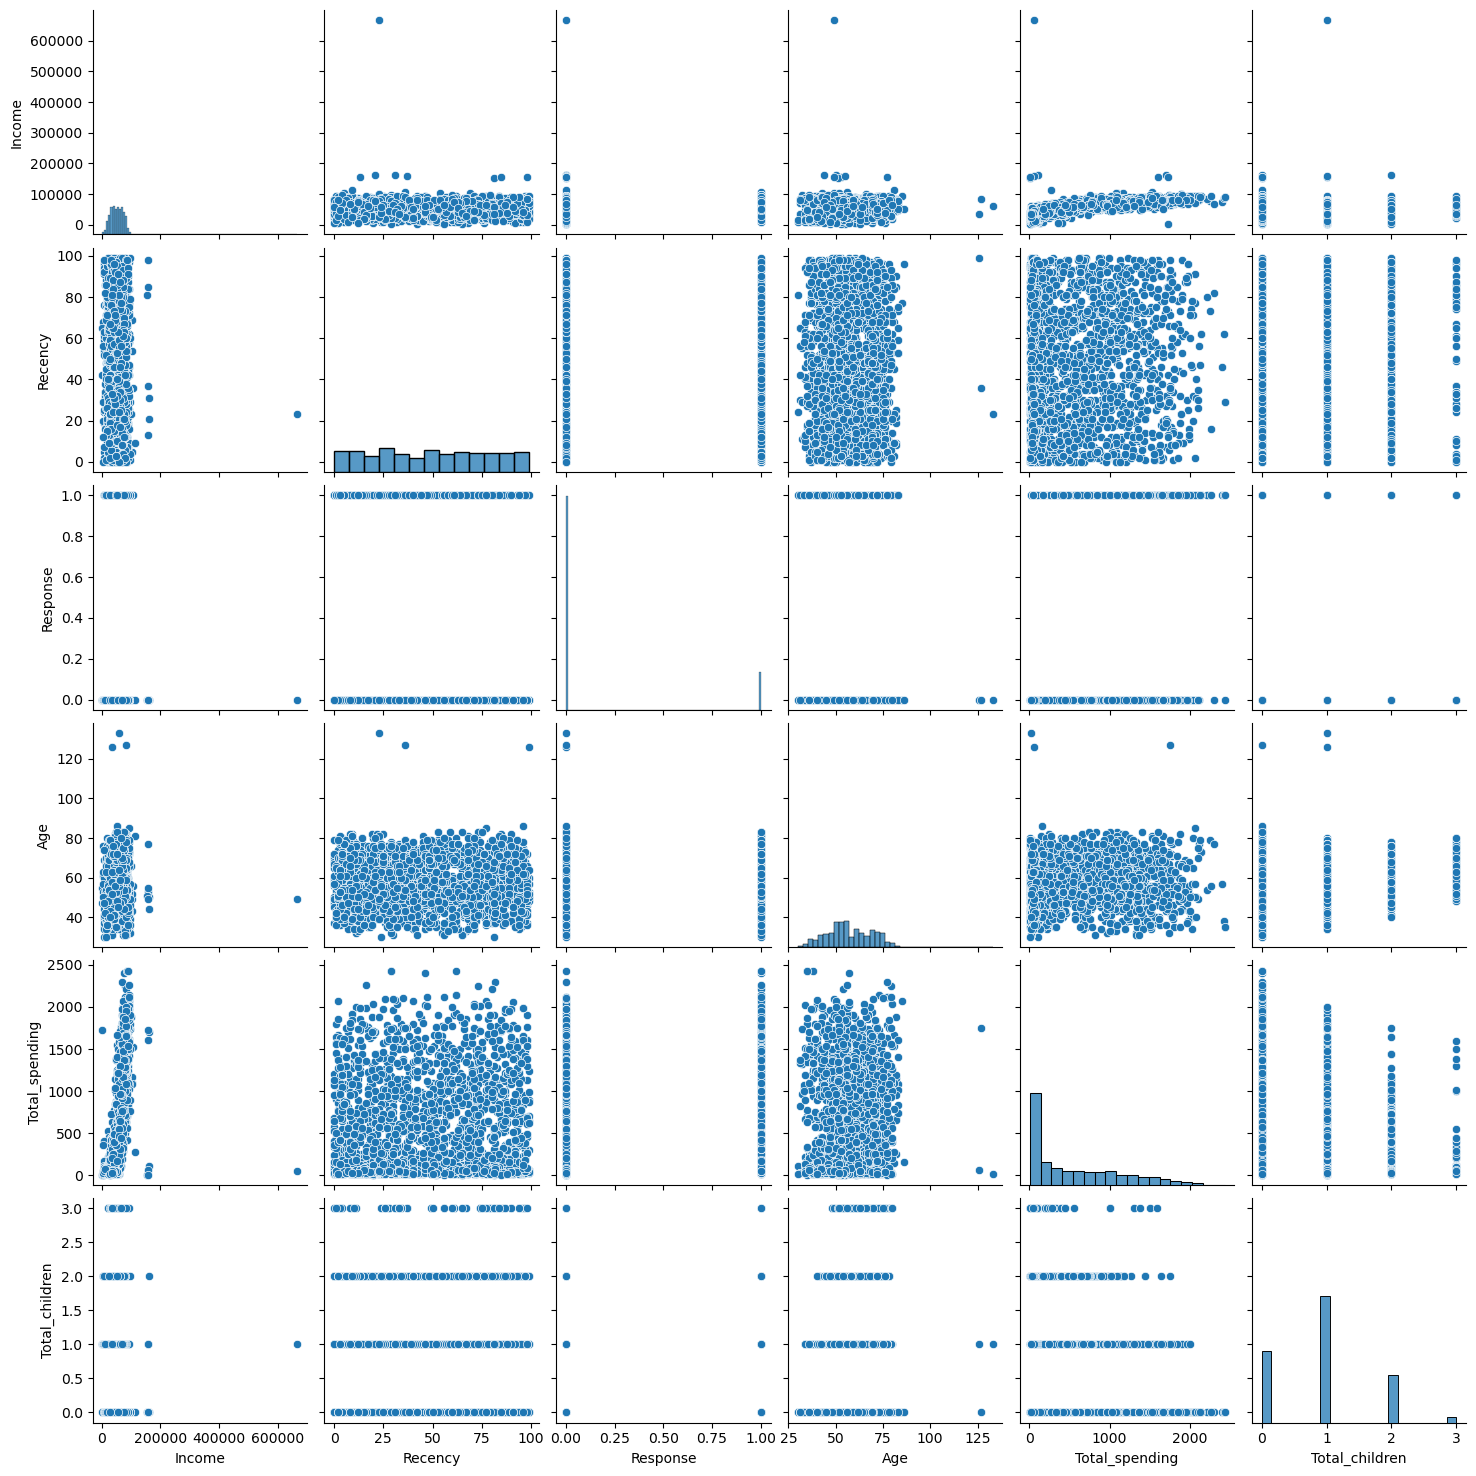

In [20]:
cols = ["Income","Recency","Response","Age","Total_spending","Total_children"]

#realtive plots of some features - pair plots
sns.pairplot (df_cleaned[cols])


In [21]:
#Remove outliers 

print("data size with ouliers : ",len(df_cleaned))

df_cleaned = df_cleaned[(df_cleaned["Age"] < 90)]
df_cleaned = df_cleaned[(df_cleaned["Income"] <600_000)]

print("data size with ouliers : ",len(df_cleaned))

data size with ouliers :  2240
data size with ouliers :  2236


### Heatmap

In [22]:
corr = df_cleaned.corr(numeric_only=True)

<Axes: >

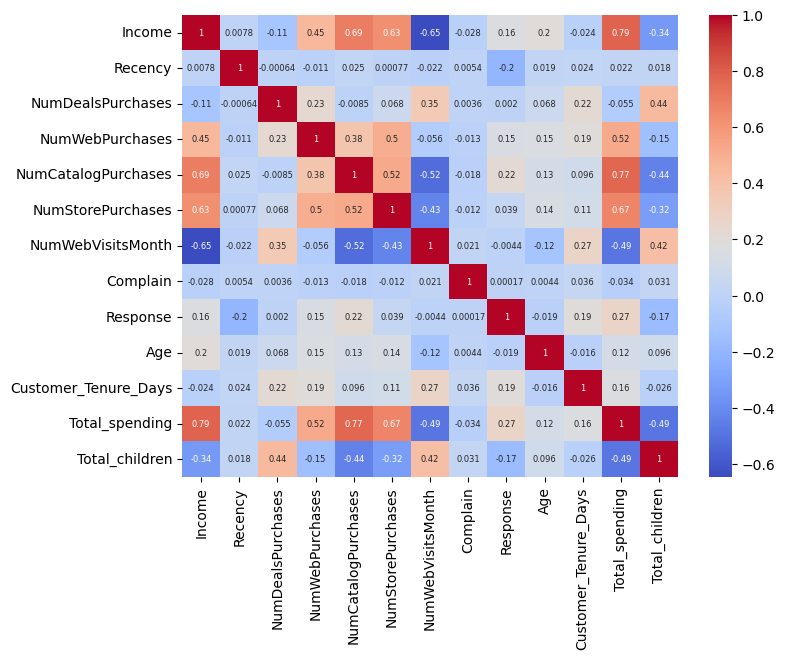

In [23]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr,
    annot=True,
    annot_kws = {"size":6},
    cmap = "coolwarm"
)

In [24]:
df_cleaned.shape

(2236, 15)

In [25]:
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_children,Living_With
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1445,0,Alone
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,25,2,Alone
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,665,0,Partner
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,43,1,Partner
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,376,1,Partner


### Encoding

In [26]:
from sklearn.preprocessing import OneHotEncoder

In [27]:
ohe = OneHotEncoder()

cat_cols = ["Education", "Living_With"]

enc_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [28]:
enc_df = pd.DataFrame(enc_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [30]:
enc_df.head()

,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,1.0,0.0,0.0,1.0,0.0
1,1.0,0.0,0.0,1.0,0.0
2,1.0,0.0,0.0,0.0,1.0
3,1.0,0.0,0.0,0.0,1.0
4,0.0,1.0,0.0,0.0,1.0


In [31]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),enc_df], axis = 1)

In [32]:
df_encoded.shape

(2236, 18)

### Scaling

In [33]:
from sklearn.preprocessing import StandardScaler

In [34]:
X = df_encoded

In [40]:
scaled = StandardScaler()

X_scaled = scaled.fit_transform(X)

### Visualize 

In [41]:
X_scaled.shape


(2236, 18)

In [42]:
#2D
from sklearn.decomposition import PCA

In [43]:
pca = PCA(n_components=3)

X_pca = pca.fit_transform(X_scaled)

Text(0.5, 0.92, '3d projection')

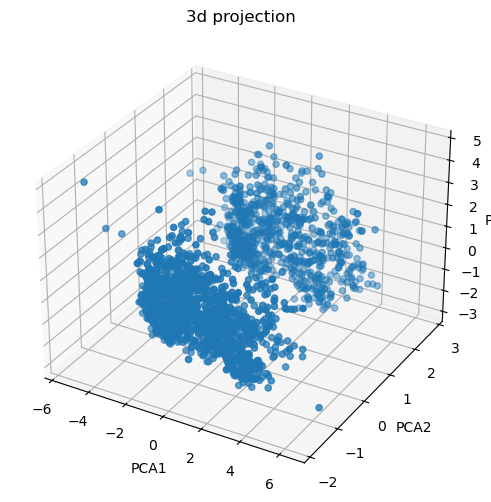

In [44]:
# plot
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

# Analyze K value
## 1. Elbow Method

In [49]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

wcss = []
for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [50]:
knee = KneeLocator(range(1, 11), wcss, curve="convex", direction="decreasing")
optimal_k = knee.elbow

In [51]:
print("best k =", optimal_k)

best k = 4


Text(0, 0.5, 'WCSS')

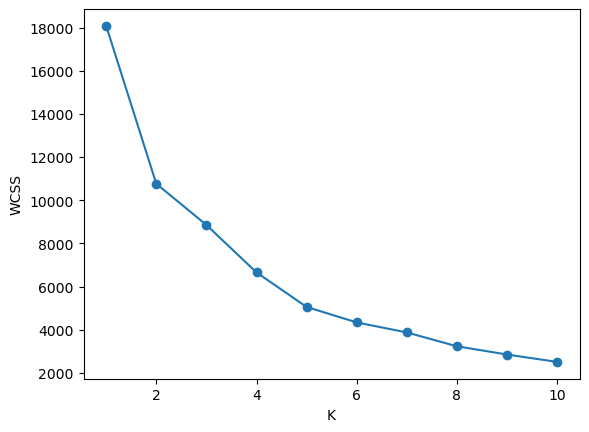

In [52]:
# plot

plt.plot(range(1,11),wcss,marker='o')
plt.xlabel("K")
plt.ylabel("WCSS")

## Silhouette Score

Text(0, 0.5, 'Silhoutte Score')

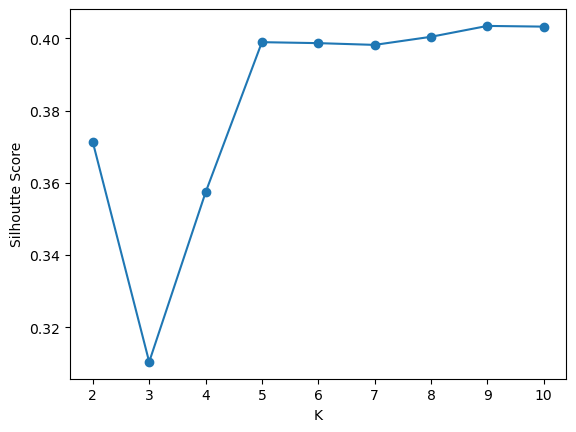

In [61]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):
    kmeans =KMeans(n_clusters=k,random_state = 42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca, labels)
    scores.append(score)

#plot
plt.plot(range(2,11),scores,marker='o')
plt.xlabel("K")
plt.ylabel("Silhoutte Score")

Text(0, 0.5, 's')

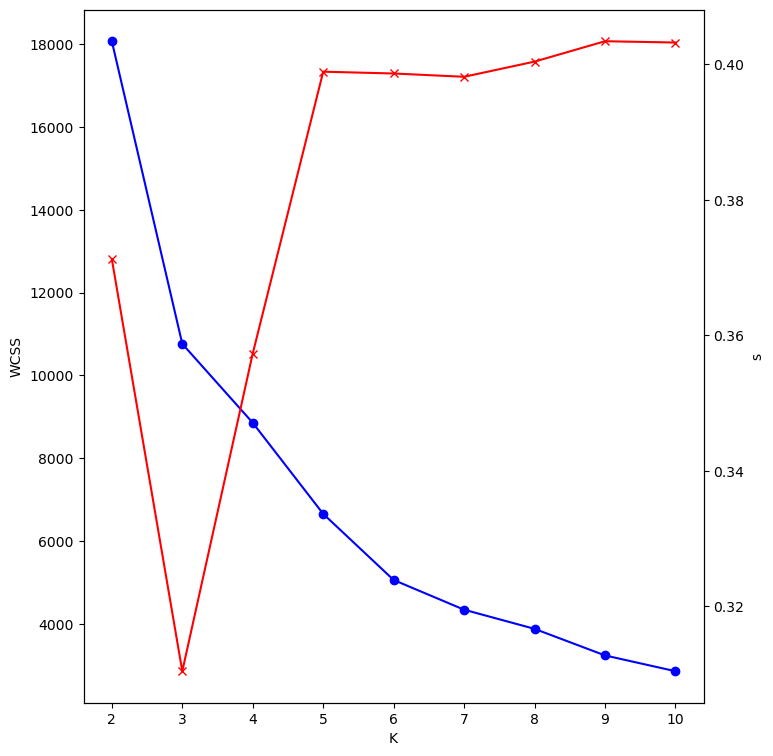

In [63]:
# Combined plot

k_range =range(2,11)

fig, ax1 = plt.subplots(figsize=(8,9))

ax1.plot(k_range,wcss[:len(k_range)],marker="o",color="blue")
ax1.set_xlabel("K")
ax1.set_ylabel("WCSS")

ax2 =ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker="x",color="red")
ax2.set_ylabel("s")


## Clustering

In [65]:
# K_means

kmeans = KMeans(n_clusters=4, random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

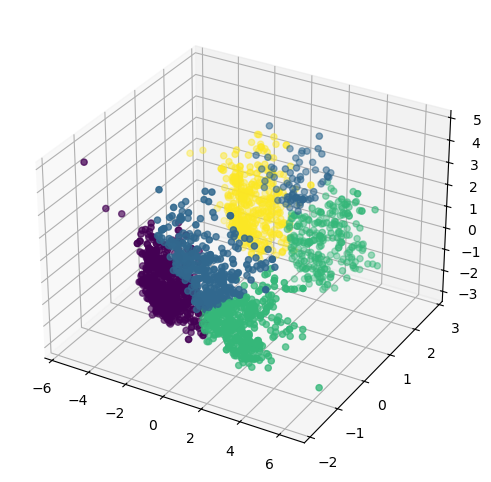

In [66]:
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot(111, projection="3d")

ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_kmeans)

In [67]:
# Agglomerative Clustering
from sklearn.cluster import AgglomerativeClustering

In [68]:
agg_clf = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg = agg_clf.fit_predict(X_pca)

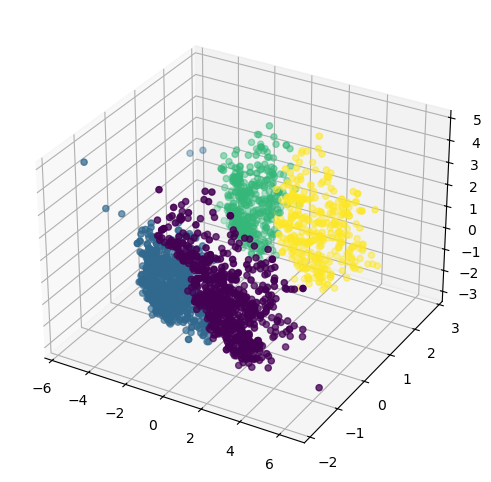

In [69]:
fig = plt.figure(figsize=(8, 6))
ax = fig.add_subplot(111, projection="3d")
ax.scatter(X_pca[:, 0], X_pca[:, 1], X_pca[:, 2], c=labels_agg)

# Characterization of Clusters

In [70]:
X["cluster"] = labels_agg

In [71]:
X.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_spending,Total_children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner,cluster
0,58138.0,58,3,8,10,4,7,0,1,69,663,1445,0,1.0,0.0,0.0,1.0,0.0,3
1,46344.0,38,2,1,1,2,5,0,0,72,113,25,2,1.0,0.0,0.0,1.0,0.0,2
2,71613.0,26,1,8,2,10,4,0,0,61,312,665,0,1.0,0.0,0.0,0.0,1.0,0
3,26646.0,26,2,2,0,4,6,0,0,42,139,43,1,1.0,0.0,0.0,0.0,1.0,1
4,58293.0,94,5,5,3,6,5,0,0,45,161,376,1,0.0,1.0,0.0,0.0,1.0,1


<Axes: xlabel='cluster', ylabel='count'>

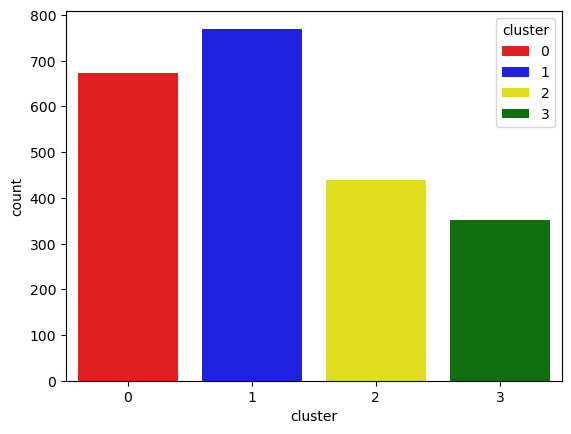

In [72]:
pal = ["red", "blue", "yellow", "green"]

sns.countplot(x=X["cluster"], palette=pal, hue=X["cluster"])

<Axes: xlabel='Total_spending', ylabel='Income'>

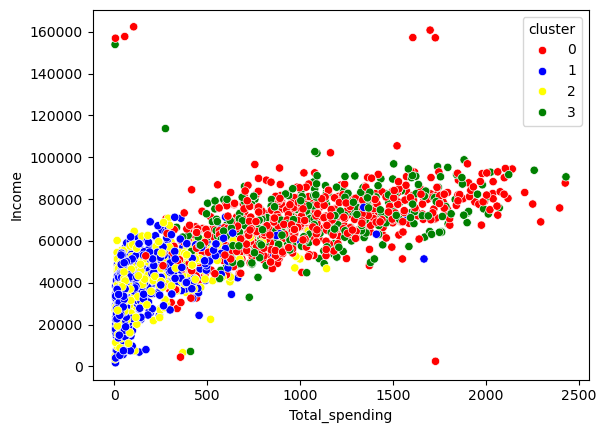

In [74]:
# Income & Spending patterns

sns.scatterplot(x=X["Total_spending"], y=X["Income"], hue=X["cluster"], palette=pal)

In [75]:
# Cluster Summary

cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        68920.603858  48.270030           2.508902         5.810089   
1        36836.898701  49.750649           2.271429         2.566234   
2        37355.992045  48.234091           2.520455         2.750000   
3        70774.174716  50.451705           1.852273         5.789773   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   4.851632           8.255193           4.105341  0.007418   
1                   0.706494           3.650649           6.429870  0.010390   
2                   0.850000           3.672727           6.509091  0.011364   
3                   5.019886           8.431818           3.724432  0.005682   

         Response        Age  Customer_Tenure_Days  Total_spending  \
cluster         